In [20]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
import torch.nn.functional as F
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

import pkbar

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_classification = pd.read_csv(
    'data/cmod_clean_200ms.csv',
    sep=',',
    index_col=None
)

shot_filter = df_classification.isna() | df_classification.isin([np.inf, -np.inf])

columns_w_nans = df_classification.columns[shot_filter.any()].tolist()

df_classification = df_classification.drop(
    columns=['shot', 'Unnamed: 0'],
    axis=1
)

df_classification = df_classification.drop(
    columns_w_nans,
    axis=1
)

df_classification = df_classification.sample(frac=1.0)

df_classification

,time,a_minor,beta_n,beta_p,chisq,dbetap_dt,dip_dt,dip_smoothed,dipprog_dt,dli_dt,...,v_loop,v_loop_efit,v_surf,v_z,wmhd,z_error,z_prog,z_times_v_z,zcur,disruptive
386934,0.96,0.217780,0.322626,0.166996,9.942101,-0.303541,-1.955485e+06,-6.441992e+04,1.278944e-12,0.442778,...,-1.694163,-1.287322,-1.373419,-0.342028,44009.179688,0.001210,-0.015,0.004717,-0.013790,0
477127,0.64,0.221677,0.428504,0.236589,9.732934,2.661187,-7.770952e+05,-3.253186e+05,8.526208e-13,-0.080106,...,-0.587112,-1.105672,-1.000198,4.738258,46524.363281,-0.001647,-0.015,-0.078882,-0.016647,0
103628,0.84,0.216558,0.295495,0.171839,9.965532,-0.496056,-3.962227e+05,-6.775584e+04,1.563162e-12,0.179556,...,-1.127787,-1.131686,-1.054595,-2.948431,31840.251953,0.000154,0.009,-0.026985,0.009154,0
373784,1.26,0.219226,0.878919,0.342143,9.293274,2.502075,7.766724e+05,-1.930082e+05,-7.673827e-12,-0.446360,...,0.509740,0.746411,0.780188,-1.930788,93521.632812,-0.002657,0.000,0.005131,-0.002657,0
420773,1.34,0.219305,0.359225,0.234615,13.558449,-0.761037,7.987906e+05,-5.856567e+05,5.115873e-12,-0.020307,...,-1.157118,-1.257107,-1.316763,-3.678017,39417.167969,-0.001947,0.000,0.007166,-0.001947,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264336,1.12,0.218111,0.280604,0.164550,10.957392,-0.161753,-6.559875e+02,-1.498884e+06,6.821177e-12,-0.159317,...,-1.867026,-1.233654,-1.105318,1.246855,29487.076172,0.000789,0.009,0.012206,0.009789,0
194318,1.10,0.214219,0.353040,0.216954,12.474471,0.192615,-2.355973e+06,-1.977853e+05,5.684308e-12,-0.400064,...,-1.116572,-1.192213,-1.113133,-5.185095,38219.070312,0.001416,-0.009,0.039340,-0.007584,0
176712,0.92,0.224792,0.526450,0.345158,8.419460,-2.683747,-6.560601e+06,-1.362110e+06,9.947921e-13,3.474178,...,1.158091,1.257209,1.483561,4.443838,53685.832031,0.000724,-0.001,-0.001226,-0.000276,0
171729,1.46,0.217505,0.301706,0.152674,14.822015,-0.213240,-1.581156e+06,-3.324120e+05,4.831655e-12,0.338543,...,-1.898777,-1.539968,-1.466742,2.499891,39927.183594,0.000553,-0.009,-0.021108,-0.008447,0


array([[<Axes: title={'center': 'time'}>,
        <Axes: title={'center': 'a_minor'}>,
        <Axes: title={'center': 'beta_n'}>,
        <Axes: title={'center': 'beta_p'}>,
        <Axes: title={'center': 'chisq'}>,
        <Axes: title={'center': 'dbetap_dt'}>,
        <Axes: title={'center': 'dip_dt'}>],
       [<Axes: title={'center': 'dip_smoothed'}>,
        <Axes: title={'center': 'dipprog_dt'}>,
        <Axes: title={'center': 'dli_dt'}>,
        <Axes: title={'center': 'dn_dt'}>,
        <Axes: title={'center': 'dwmhd_dt'}>,
        <Axes: title={'center': 'greenwald_fraction'}>,
        <Axes: title={'center': 'ip'}>],
       [<Axes: title={'center': 'ip_error'}>,
        <Axes: title={'center': 'ip_prog'}>,
        <Axes: title={'center': 'kappa'}>,
        <Axes: title={'center': 'kappa_area'}>,
        <Axes: title={'center': 'li'}>,
        <Axes: title={'center': 'lower_gap'}>,
        <Axes: title={'center': 'n_e'}>],
       [<Axes: title={'center': 'p_icrf'}>,
       

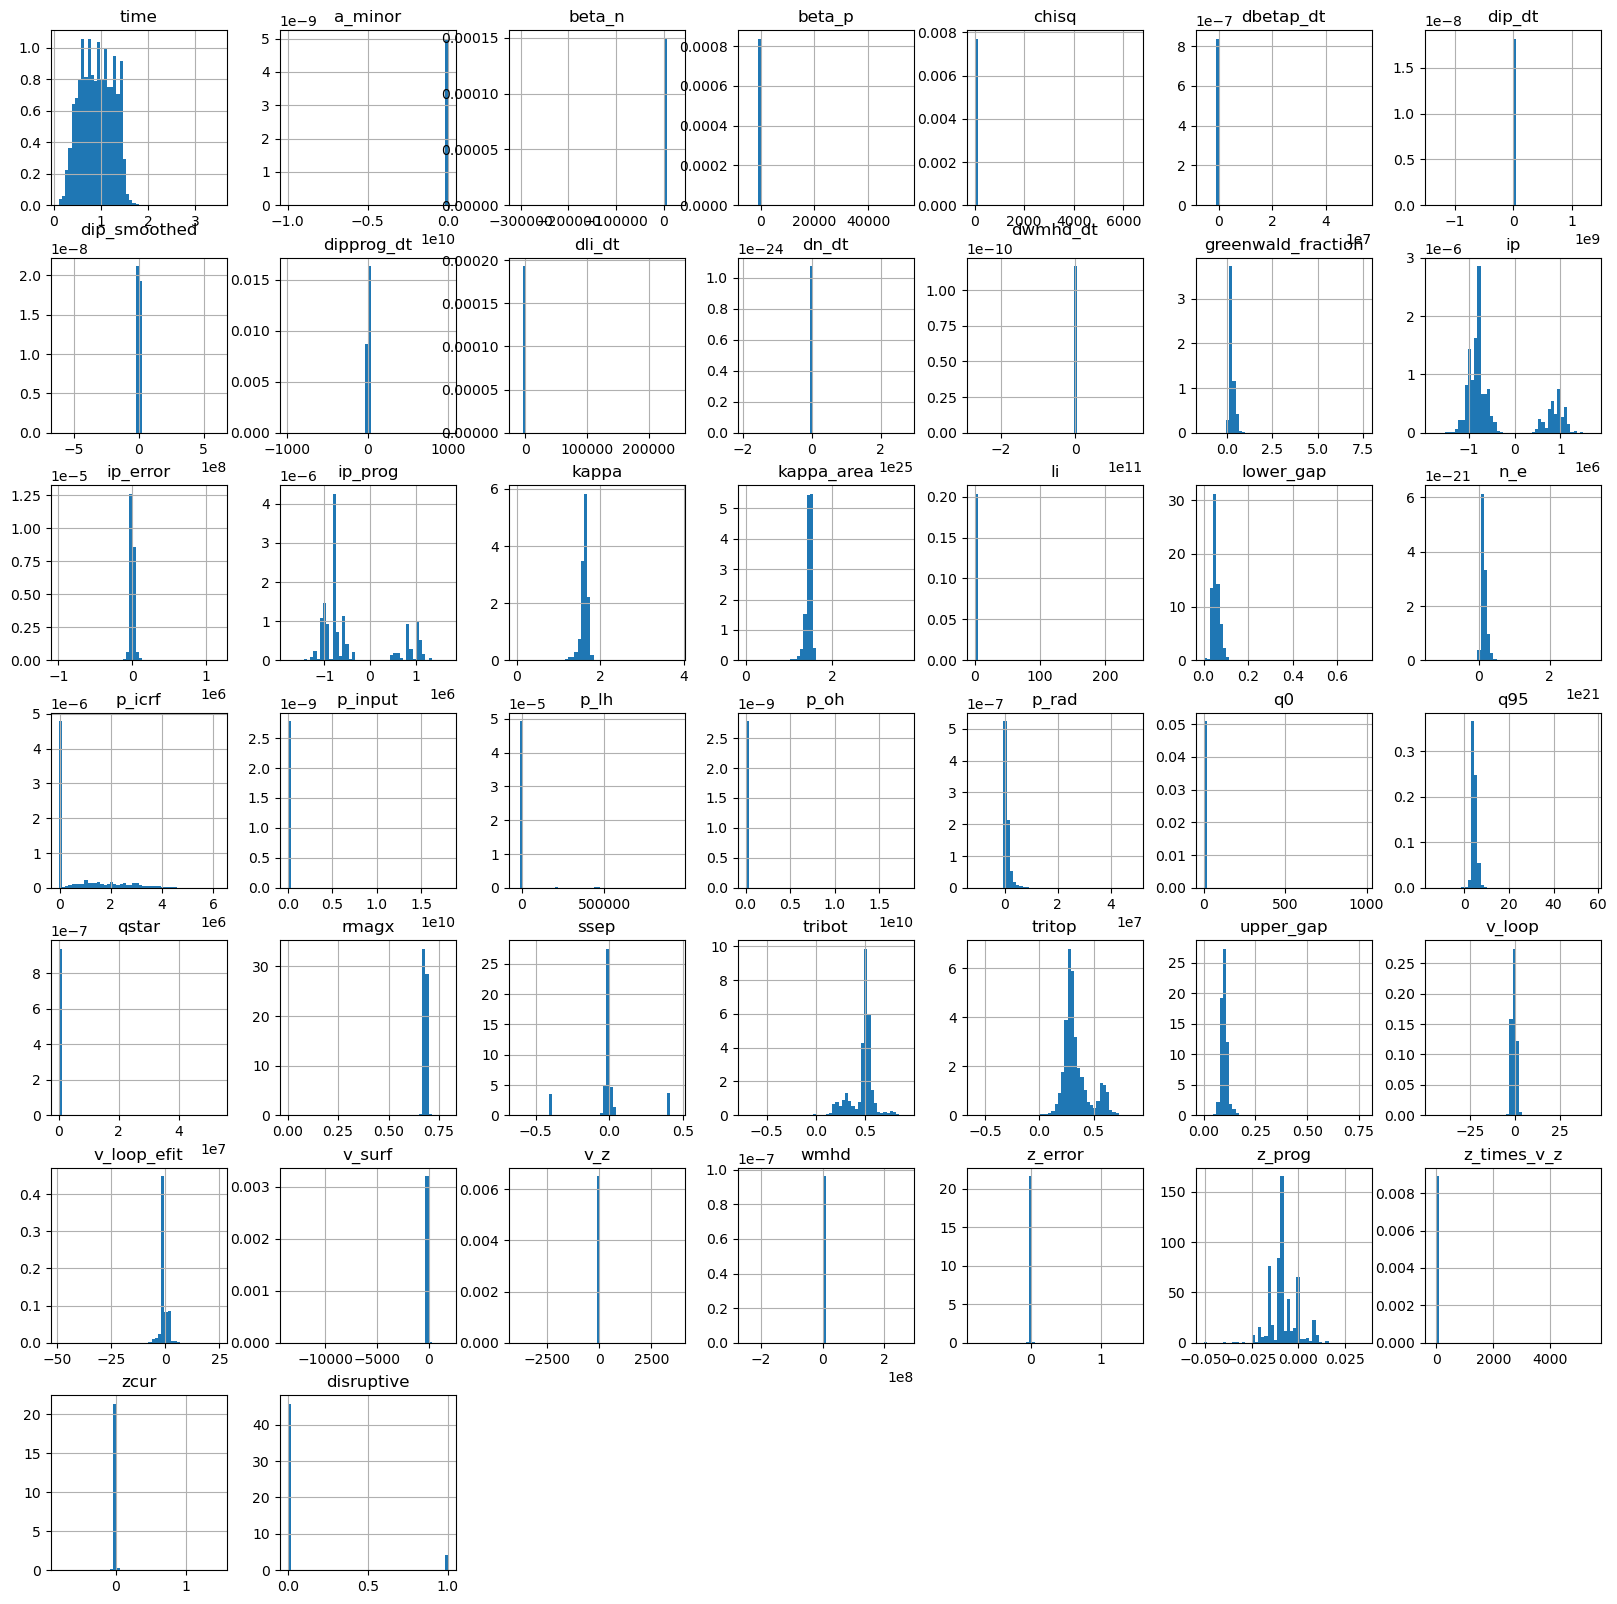

In [24]:
df_classification.hist(figsize=(20,20),bins=50,density=True)

In [29]:
from sklearn.preprocessing import MinMaxScaler

def create_train_test_split(dataset):

    def return_x_y(dataframe):
        x = dataframe.drop(columns=['time_until_disrupt', 'disruptive'], errors='ignore').to_numpy()
        y = dataframe['disruptive'].values
        return x, y

    Nt = int(0.7 * len(dataset))
    train = dataset.iloc[:Nt]
    test_val = dataset.iloc[Nt:]

    Nv = int(0.5 * len(test_val))
    val = test_val.iloc[:Nv]
    test = test_val.iloc[Nv:]

    print("Total dataset size:", len(dataset))
    print("Number of Training data points:", len(train))
    print("Number of Validation data points:", len(val))
    print("Number of Testing data points:", len(test))

    train_x, train_y = return_x_y(train)
    val_x, val_y = return_x_y(val)
    test_x, test_y = return_x_y(test)

    scaler = MinMaxScaler()
    train_x = scaler.fit_transform(train_x)
    val_x = scaler.transform(val_x)
    test_x = scaler.transform(test_x)

    return train_x, train_y, val_x, val_y, test_x, test_y

train_x, train_y, val_x, val_y, test_x, test_y = create_train_test_split(df_classification)

Total dataset size: 526251
Number of Training data points: 368375
Number of Validation data points: 78938
Number of Testing data points: 78938


In [30]:
feature_scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit on training data only (best practice)
feature_scaler.fit(train_x.astype('float32'))

x_train_scaled = feature_scaler.transform(train_x.astype('float32'))
x_val_scaled = feature_scaler.transform(val_x.astype('float32'))
x_test_scaled = feature_scaler.transform(test_x.astype('float32'))

print("Features")
print("Training:", x_train_scaled.max(), x_train_scaled.min())
print("Validation:", x_val_scaled.max(), x_val_scaled.min())
print("Testing:", x_test_scaled.max(), x_test_scaled.min())

y_train_scaled = train_y.astype('float32')
y_val_scaled = val_y.astype('float32')
y_test_scaled = test_y.astype('float32')

print("\nTargets")
print("Training:", y_train_scaled.max(), y_train_scaled.min())
print("Validation:", y_val_scaled.max(), y_val_scaled.min())
print("Testing:", y_test_scaled.max(), y_test_scaled.min())

print("Features shape:", x_train_scaled.shape)

Features
Training: 1.0 -1.0
Validation: 1.8127391 -1.157213
Testing: 30.339119 -1.0858469

Targets
Training: 1.0 0.0
Validation: 1.0 0.0
Testing: 1.0 0.0
Features shape: (368375, 43)


In [31]:
import torch
from torch import nn
from torch.nn import BatchNorm1d

class MLP(nn.Module):
    def __init__(self,input_shape,output_shape):
        super(MLP, self).__init__()

        self.init_layer = nn.Linear(input_shape,64)
        self.B0 = nn.BatchNorm1d(64)
        self.L1 = nn.Linear(64,256)
        self.B1 = nn.BatchNorm1d(256)
        self.L2 = nn.Linear(256,512)
        self.B2 = nn.BatchNorm1d(512)
        self.L3 = nn.Linear(512,256)
        self.B3 = nn.BatchNorm1d(256)
        self.L4 = nn.Linear(256,128)
        self.B4 = nn.BatchNorm1d(128)
        self.output = nn.Linear(128,output_shape)
        self.activation = nn.SELU()
        self.output_activation = nn.Sigmoid()
    def forward(self,x):

        x = self.activation(self.B0(self.init_layer(x))) # SELU(BNorm(Linear(x)))
        x = self.activation(self.B1(self.L1(x)))
        x = self.activation(self.B2(self.L2(x)))
        x = self.activation(self.B3(self.L3(x)))
        x = self.activation(self.B4(self.L4(x)))
        x = self.output_activation(self.output(x)) # Sigmoid is obvious choice here, constrain to probabalistic interval (0,1)

        return x

classifier = MLP(input_shape=x_train_scaled.shape[1],output_shape=1) # Singular output
print(classifier)

MLP(
  (init_layer): Linear(in_features=43, out_features=64, bias=True)
  (B0): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (L1): Linear(in_features=64, out_features=256, bias=True)
  (B1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (L2): Linear(in_features=256, out_features=512, bias=True)
  (B2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (L3): Linear(in_features=512, out_features=256, bias=True)
  (B3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (L4): Linear(in_features=256, out_features=128, bias=True)
  (B4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (output): Linear(in_features=128, out_features=1, bias=True)
  (activation): SELU()
  (output_activation): Sigmoid()
)


In [32]:
classifier(torch.tensor(x_train_scaled[:3]).float())

tensor([[0.3259],
        [0.6381],
        [0.5363]], grad_fn=<SigmoidBackward0>)

In [33]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(torch.tensor(x_train_scaled),torch.tensor(y_train_scaled.reshape(-1,1)))
val_dataset = TensorDataset(torch.tensor(x_val_scaled),torch.tensor(y_val_scaled.reshape(-1,1)))
test_dataset = TensorDataset(torch.tensor(x_test_scaled),torch.tensor(y_test_scaled.reshape(-1,1)))

In [34]:
train_dataset.__getitem__(0)

(tensor([-0.4963,  1.0000,  0.8404, -0.8769, -0.9969, -0.8768,  0.0060, -0.0205,
          0.0000, -0.8919, -0.1724,  0.3335, -0.6484, -0.5520, -0.0735, -0.5429,
          0.1581,  0.1816, -0.9892, -0.8944, -0.3468, -0.9890, -0.9998, -0.9993,
         -0.9998, -0.6168, -0.9704, -0.3695, -1.0000,  0.7690, -0.5802,  0.4956,
          0.1496, -0.7624, -0.0754,  0.2964,  0.7588,  0.0298, -0.0364, -0.2964,
         -0.1667, -0.9549, -0.3017]),
 tensor([0.]))

In [35]:
train_loader = DataLoader(train_dataset,batch_size=10)

for i,data in enumerate(train_loader):
    x = data[0]
    y = data[1]
    print("Batch {0}".format(i),"-> x shape: ",x.shape," y shape: ",y.shape)
    break

Batch 0 -> x shape:  torch.Size([10, 43])  y shape:  torch.Size([10, 1])


In [36]:
# Create dataloaders to iterate.
# We take as input the three TensorDatasets along with the batch sizes we want to use.
def CreateLoaders(train_dataset,val_dataset,test_dataset,train_batch,val_batch,test_batch):
    train_loader = DataLoader(train_dataset,
                            batch_size=train_batch,
                            shuffle=True)
    val_loader =  DataLoader(val_dataset,
                            batch_size=val_batch,
                            shuffle=False)
    test_loader =  DataLoader(test_dataset,
                            batch_size=val_batch,
                            shuffle=False)
    return train_loader,val_loader,test_loader

train_loader,val_loader,test_loader = CreateLoaders(train_dataset,val_dataset,test_dataset,10,10,10)

In [37]:
!nvidia-smi

Tue Jun  9 20:21:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:21:00.0 Off |                    0 |
|  0%   38C    P0            107W /  300W |     633MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [64]:
config = {"seed":8,
          "name": "MyClassifier",
          "run_val":1,
          "model": {
               "input_shape":28,
               "output_shape": 1,
           },
          "optimizer": {
                "lr": 7e-4,
            },
          "num_epochs": 20,
          "dataloader": {
            "train": {
                "batch_size": 100
            },
            "val": {
                "batch_size": 100
            },
            "test": {
                "batch_size": 100
            },
          },
            "output": {
                "dir":"./"
            }
}

In [65]:
import os
import json
import random
import pkbar
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np


def trainer(config, train_dataset, val_dataset, test_dataset):
    # Setup random seed
    torch.manual_seed(config['seed'])
    np.random.seed(config['seed'])
    random.seed(config['seed'])

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if torch.cuda.is_available():
        torch.cuda.manual_seed(config['seed'])

    # Create experiment name
    exp_name = config['name']
    print(exp_name)

    # Create directory structure
    output_folder = config['output']['dir']
    output_path = os.path.join(output_folder, exp_name)
    os.makedirs(output_path, exist_ok=True)

    with open(os.path.join(output_path, 'config.json'), 'w') as outfile:
        json.dump(config, outfile)

    # Load the dataset
    print('Creating Loaders.')

    train_batch_size = config['dataloader']['train']['batch_size']
    val_batch_size = config['dataloader']['val']['batch_size']
    test_batch_size = config['dataloader']['val']['batch_size']

    train_loader, val_loader, test_loader = CreateLoaders(
        train_dataset,
        val_dataset,
        test_dataset,
        train_batch_size,
        val_batch_size,
        test_batch_size
    )

    history = {
        'train_loss': [],
        'val_loss': [],
        'lr': []
    }

    print("Training Size: {0}".format(len(train_loader.dataset)))
    print("Validation Size: {0}".format(len(val_loader.dataset)))

    # Create the model
    input_shape = train_dataset.tensors[0].shape[1]
    output_shape = config['model']['output_shape']

    net = MLP(input_shape=input_shape, output_shape=output_shape)

    t_params = sum(p.numel() for p in net.parameters())
    print("Network Parameters:", t_params)

    net.to(device)

    # Optimizer
    num_epochs = int(config['num_epochs'])
    lr = float(config['optimizer']['lr'])

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, net.parameters()),
        lr=lr
    )

    num_steps = len(train_loader) * num_epochs

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer=optimizer,
        T_max=num_steps,
        last_epoch=-1,
        eta_min=0
    )

    startEpoch = 0
    global_step = 0

    print('===========  Optimizer  ==================:')
    print('      LR:', lr)
    print('      num_epochs:', num_epochs)
    print('')

    # Get training labels from TensorDataset
    all_train_y = train_dataset.tensors[1].cpu().numpy().astype(int).ravel()

    class_counts = np.bincount(all_train_y)

    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum() * len(class_weights)

    pos_weight = class_weights[1] / class_weights[0]
    pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)

    # Since your model already has Sigmoid(), use BCELoss
    loss_function = nn.BCELoss(reduction='none')

    for epoch in range(startEpoch, num_epochs):

        kbar = pkbar.Kbar(
            target=len(train_loader),
            epoch=epoch,
            num_epochs=num_epochs,
            width=20,
            always_stateful=False
        )

        net.train()
        running_loss = 0.0

        for i, data in enumerate(train_loader):
            inputs = data[0].to(device).float()
            y = data[1].to(device).float().view(-1, 1)

            optimizer.zero_grad()

            y_hat = net(inputs)

            # Per-sample class weighting
            weights = torch.ones_like(y)
            weights[y == 1] = pos_weight

            loss = loss_function(y_hat, y)
            loss = (loss * weights).mean()

            train_acc = (torch.round(y_hat) == y).float().mean().item()

            loss.backward()
            optimizer.step()
            scheduler.step()

            running_loss += loss.item() * inputs.shape[0]

            kbar.update(
                i,
                values=[
                    ("loss", loss.item()),
                    ("train_acc", train_acc)
                ]
            )

            global_step += 1

        epoch_train_loss = running_loss / len(train_loader.dataset)

        history['train_loss'].append(epoch_train_loss)
        history['lr'].append(scheduler.get_last_lr()[0])

        ######################
        ## validation phase ##
        ######################
        if bool(config['run_val']):
            net.eval()

            val_loss = 0.0
            val_acc = 0.0

            with torch.no_grad():
                for i, data in enumerate(val_loader):
                    inputs = data[0].to(device).float()
                    y = data[1].to(device).float().view(-1, 1)

                    y_hat = net(inputs)

                    weights = torch.ones_like(y)
                    weights[y == 1] = pos_weight

                    loss = loss_function(y_hat, y)
                    loss = (loss * weights).mean()

                    val_acc += (torch.round(y_hat) == y).float().mean().item()
                    val_loss += loss.item()

            val_loss = val_loss / len(val_loader)
            val_acc = val_acc / len(val_loader)

            history['val_loss'].append(val_loss)

            kbar.add(
                1,
                values=[
                    ("val_loss", val_loss),
                    ("val_acc", val_acc)
                ]
            )

            name_output_file = (
                config['name']
                + '_epoch{:02d}_val_loss_{:.6f}.pth'.format(epoch, val_loss)
            )

        else:
            kbar.add(1, values=[('val_loss', 0.)])

            name_output_file = (
                config['name']
                + '_epoch{:02d}_train_loss_{:.6f}.pth'.format(epoch, epoch_train_loss)
            )

        filename = os.path.join(output_path, name_output_file)

        checkpoint = {}
        checkpoint['net_state_dict'] = net.state_dict()
        checkpoint['optimizer'] = optimizer.state_dict()
        checkpoint['scheduler'] = scheduler.state_dict()
        checkpoint['epoch'] = epoch
        checkpoint['history'] = history
        checkpoint['global_step'] = global_step

        torch.save(checkpoint, filename)

        print('')

    return net, history

In [66]:
trainer(config,train_dataset,val_dataset,test_dataset)

MyClassifier
Creating Loaders.
Training Size: 368375
Validation Size: 78938
Network Parameters: 317825
===========  Optimizer  ==================:
      LR: 0.0007
      num_epochs: 20

Epoch: 1/20
3684/3684 [====================] - 12s 3ms/step - loss: 0.6234 - train_acc: 0.9196 - val_loss: 0.5985 - val_acc: 0.9491

Epoch: 2/20
3684/3684 [====================] - 12s 3ms/step - loss: 0.5736 - train_acc: 0.9347 - val_loss: 0.5793 - val_acc: 0.9641

Epoch: 3/20
3684/3684 [====================] - 12s 3ms/step - loss: 0.5548 - train_acc: 0.9358 - val_loss: 0.5294 - val_acc: 0.9584

Epoch: 4/20
3684/3684 [====================] - 12s 3ms/step - loss: 0.5400 - train_acc: 0.9354 - val_loss: 0.5556 - val_acc: 0.9659

Epoch: 5/20
3684/3684 [====================] - 12s 3ms/step - loss: 0.5249 - train_acc: 0.9355 - val_loss: 0.5456 - val_acc: 0.8737

Epoch: 6/20
3684/3684 [====================] - 12s 3ms/step - loss: 0.5158 - train_acc: 0.9354 - val_loss: 0.5777 - val_acc: 0.8394

Epoch: 7/20
3684

(MLP(
   (init_layer): Linear(in_features=43, out_features=64, bias=True)
   (B0): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (L1): Linear(in_features=64, out_features=256, bias=True)
   (B1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (L2): Linear(in_features=256, out_features=512, bias=True)
   (B2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (L3): Linear(in_features=512, out_features=256, bias=True)
   (B3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (L4): Linear(in_features=256, out_features=128, bias=True)
   (B4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (output): Linear(in_features=128, out_features=1, bias=True)
   (activation): SELU()
   (output_activation): Sigmoid()
 ),
 {'train_loss': [0.6236424222856527,
   0.573556312626404,
   0.5546951791594544,
   0.5399984947960378,

In [67]:
checkpoint_dir = os.path.join(config['output']['dir'], config['name'])

pth_files = [f for f in os.listdir(checkpoint_dir) if f.endswith(".pth")]
latest_file = sorted(pth_files)[-1]

dicte = torch.load(
    os.path.join(checkpoint_dir, latest_file),
    map_location="cpu"
)

print(dicte.keys())

dict_keys(['net_state_dict', 'optimizer', 'scheduler', 'epoch', 'history', 'global_step'])


/tmp/ipykernel_2585/4230760654.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dicte = torch.load(


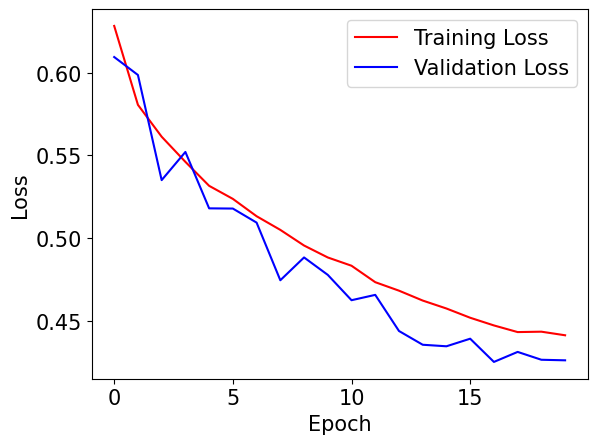

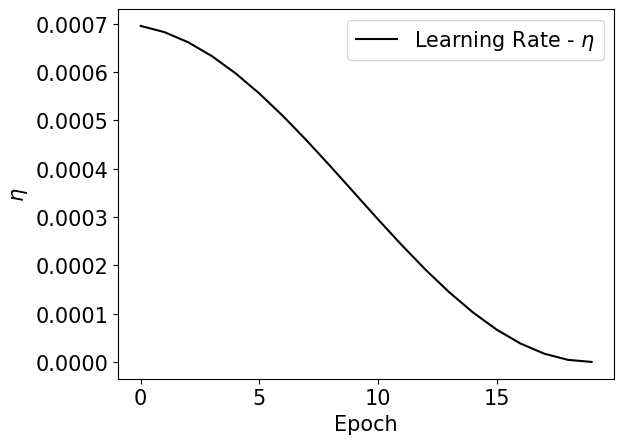

In [68]:
import matplotlib.pyplot as plt

train_loss = dicte['history']['train_loss']
val_loss = dicte['history']['val_loss']
learning_rate = dicte['history']['lr']

plt.plot(train_loss,'r-',label="Training Loss")
plt.plot(val_loss,'b-',label='Validation Loss')
plt.legend(fontsize=15)
plt.xlabel('Epoch',fontsize=15)
plt.ylabel('Loss',fontsize=15)
plt.tick_params(axis='both', labelsize=15)
plt.show()

plt.plot(learning_rate,'k-',label=r"Learning Rate - $\eta$")
plt.legend(fontsize=15)
plt.xlabel('Epoch',fontsize=15)
plt.ylabel(r'$\eta$',fontsize=15)
plt.tick_params(axis='both', labelsize=15)
plt.show()

In [69]:
config['model']['input_shape'] = x_train_scaled.shape[1]

input_shape = config['model']['input_shape']
output_shape = config['model']['output_shape']

net = MLP(input_shape=input_shape, output_shape=output_shape)

t_params = sum(p.numel() for p in net.parameters())
print("Network Parameters:", t_params)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net.to(device)

checkpoint_dir = os.path.join(config['output']['dir'], config['name'])

pth_files = [f for f in os.listdir(checkpoint_dir) if f.endswith(".pth")]
latest_file = sorted(pth_files)[-1]

dicte = torch.load(
    os.path.join(checkpoint_dir, latest_file),
    map_location=device
)

net.load_state_dict(dicte["net_state_dict"])
net.eval()

Network Parameters: 317825


/tmp/ipykernel_2585/1434512596.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dicte = torch.load(


MLP(
  (init_layer): Linear(in_features=43, out_features=64, bias=True)
  (B0): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (L1): Linear(in_features=64, out_features=256, bias=True)
  (B1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (L2): Linear(in_features=256, out_features=512, bias=True)
  (B2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (L3): Linear(in_features=512, out_features=256, bias=True)
  (B3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (L4): Linear(in_features=256, out_features=128, bias=True)
  (B4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (output): Linear(in_features=128, out_features=1, bias=True)
  (activation): SELU()
  (output_activation): Sigmoid()
)

In [70]:
test_loader = DataLoader(test_dataset,batch_size=config['dataloader']['test']['batch_size'])
net.eval() # Eval mode

predictions = []
y_true = []
kbar = pkbar.Kbar(target=len(test_loader), width=20, always_stateful=False)
for i,data in enumerate(test_loader):
    x = data[0].to('cuda').float()
    y_true.append(data[1].numpy())

    with torch.set_grad_enabled(False): # Same as with torch.no_grad():
        y_hat = net(x).detach().cpu().numpy()

    predictions.append(y_hat)

    kbar.update(i)

predictions = np.concatenate(predictions)
y_true = np.concatenate(y_true)

779/790 [==================>.] - ETA: 0s

AUC: 0.96


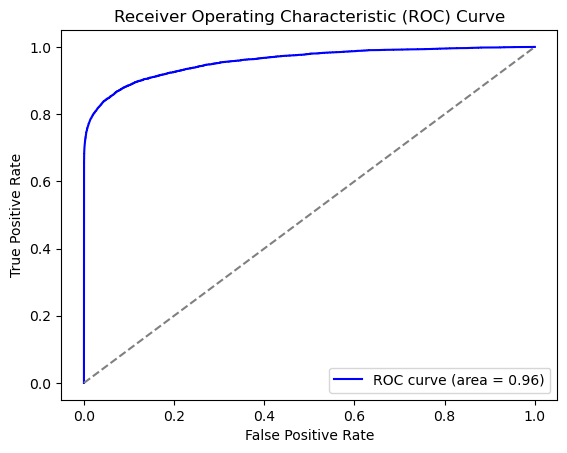

In [71]:
from sklearn.metrics import roc_curve, roc_auc_score

# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_true, predictions)

# Calculate the AUC (Area Under the Curve)
auc = roc_auc_score(y_true, predictions)
print(f"AUC: {auc:.2f}")

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Confusion Matrix:
 [[69675  2716]
 [ 1126  5421]]


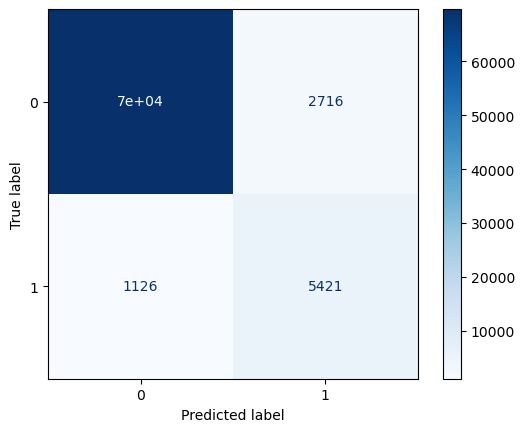

In [74]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report,ConfusionMatrixDisplay

cm = confusion_matrix(y_true, predictions.round())
print("Confusion Matrix:\n", cm)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [73]:
print(classification_report(y_true,predictions.round()))

# Compute metrics
precision = precision_score(y_true, predictions.round())
recall = recall_score(y_true, predictions.round())
f1 = f1_score(y_true, predictions.round())

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97     72391
         1.0       0.67      0.83      0.74      6547

    accuracy                           0.95     78938
   macro avg       0.83      0.90      0.86     78938
weighted avg       0.96      0.95      0.95     78938

Precision: 0.6662160501413297
Recall: 0.828012830303956
F1 Score: 0.7383546717515663
